<a href="https://colab.research.google.com/github/gabis0604/projetos-da-faculdade-linguagem-de-sistemas/blob/main/aula_4_unidade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##AULA 4 UNIDADE 3


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/wcota/covid19br/master/cases-brazil-states.csv"
df = pd.read_csv(url)
df_raw = pd.read_csv(url)

In [7]:
df.head()

,epi_week,date,country,state,city,newDeaths,deaths,newCases,totalCases,deathsMS,...,tests,tests_per_100k_inhabitants,vaccinated,vaccinated_per_100_inhabitants,vaccinated_second,vaccinated_second_per_100_inhabitants,vaccinated_single,vaccinated_single_per_100_inhabitants,vaccinated_third,vaccinated_third_per_100_inhabitants
0,9,2020-02-25,Brazil,SP,TOTAL,0,0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9,2020-02-25,Brazil,TOTAL,TOTAL,0,0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9,2020-02-26,Brazil,SP,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,2020-02-26,Brazil,TOTAL,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9,2020-02-27,Brazil,SP,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df = df_raw[df_raw['state'] == 'TOTAL'].copy()

In [17]:
df.head()

,epi_week,date,country,state,city,newDeaths,deaths,newCases,totalCases,deathsMS,...,tests,tests_per_100k_inhabitants,vaccinated,vaccinated_per_100_inhabitants,vaccinated_second,vaccinated_second_per_100_inhabitants,vaccinated_single,vaccinated_single_per_100_inhabitants,vaccinated_third,vaccinated_third_per_100_inhabitants
1,9,2020-02-25,Brazil,TOTAL,TOTAL,0,0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,2020-02-26,Brazil,TOTAL,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9,2020-02-27,Brazil,TOTAL,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9,2020-02-28,Brazil,TOTAL,TOTAL,0,0,1,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,2020-02-29,Brazil,TOTAL,TOTAL,0,0,0,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df['date'] = pd.to_datetime(df['date'])

In [19]:
df.head(1)

,epi_week,date,country,state,city,newDeaths,deaths,newCases,totalCases,deathsMS,...,tests,tests_per_100k_inhabitants,vaccinated,vaccinated_per_100_inhabitants,vaccinated_second,vaccinated_second_per_100_inhabitants,vaccinated_single,vaccinated_single_per_100_inhabitants,vaccinated_third,vaccinated_third_per_100_inhabitants
1,9,2020-02-25,Brazil,TOTAL,TOTAL,0,0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df = df[['date', 'newCases', 'newDeaths', 'totalCases']].reset_index(drop=True)

In [22]:
df.head(2)

,date,newCases,newDeaths,totalCases
0,2020-02-25,1,0,1
1,2020-02-26,0,0,1


In [23]:
print(f"Dados de {df['date'].min()} até {df['date'].max().date()}")
print(f"Total de dias registrados: {len(df)}")

Dados de 2020-02-25 00:00:00 até 2023-03-18
Total de dias registrados: 1118


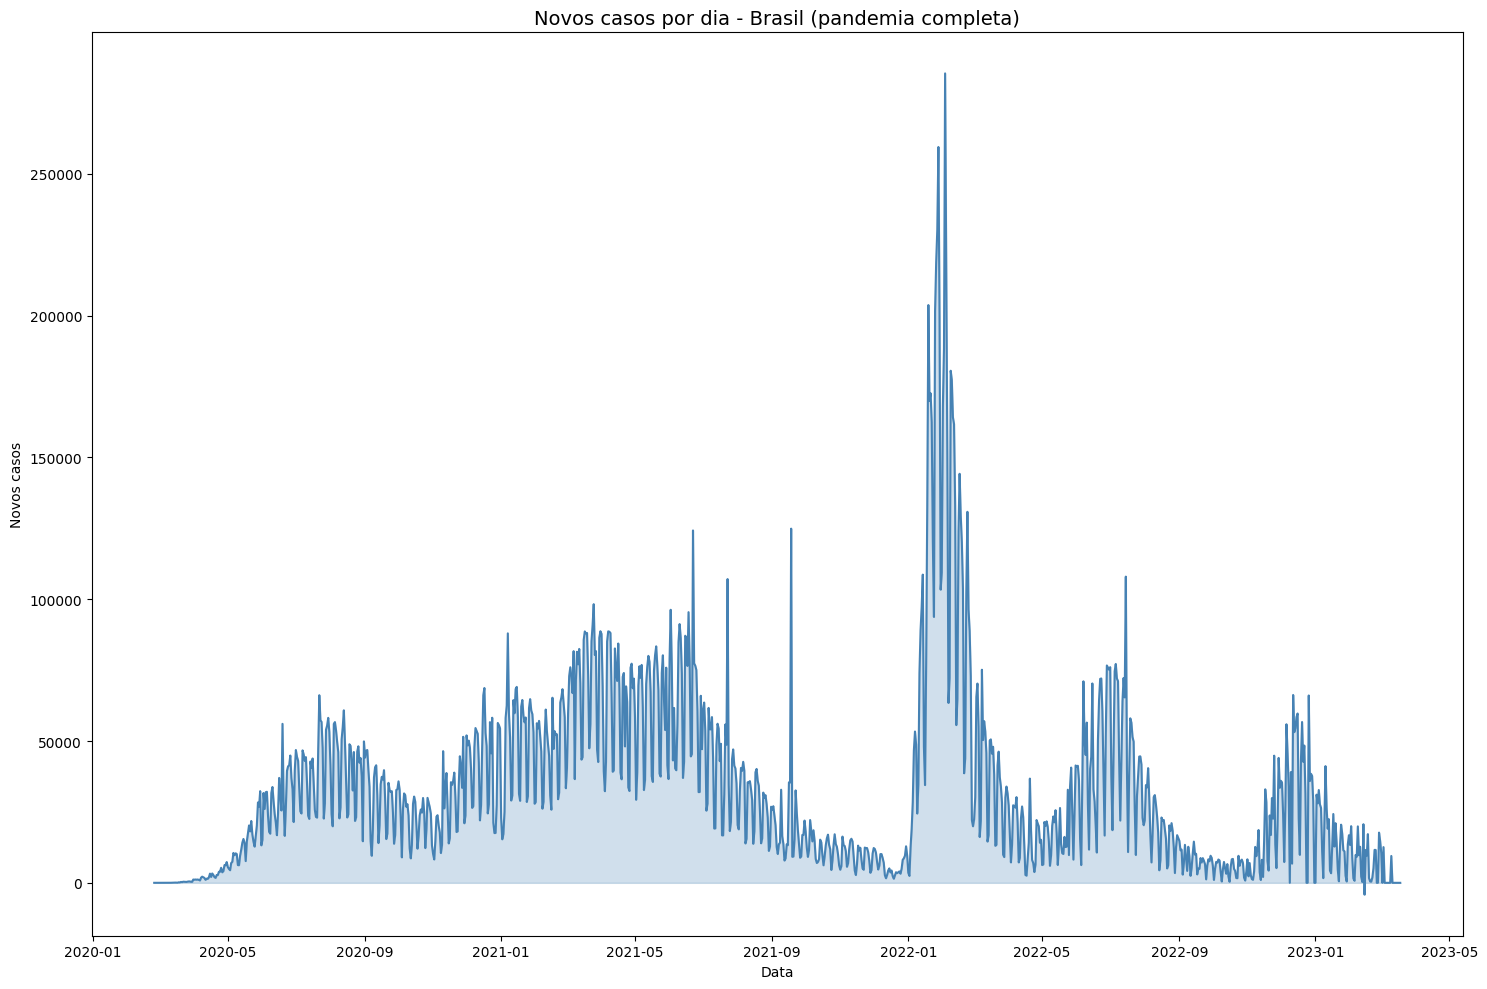

In [24]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.plot(df['date'], df['newCases'], color='steelblue', linewidth=1.5)
ax.fill_between(df['date'], df['newCases'], alpha=0.25, color='steelblue')
ax.set_title("Novos casos por dia - Brasil (pandemia completa)", fontsize=14)
ax.set_xlabel("Data")
ax.set_ylabel("Novos casos")
plt.tight_layout()
plt.show()

In [35]:
ondas = [
    ("1º onda", "2020-07-15", "steelblue"),
    ("2º onda", "2021-03-25", "tomato"),
    ("3º onda", "2022-02-01", "steelblue")
]

In [36]:
ondas

[('1º onda', '2020-07-15', 'steelblue'),
 ('2º onda', '2021-03-25', 'tomato'),
 ('3º onda', '2022-02-01', 'steelblue')]

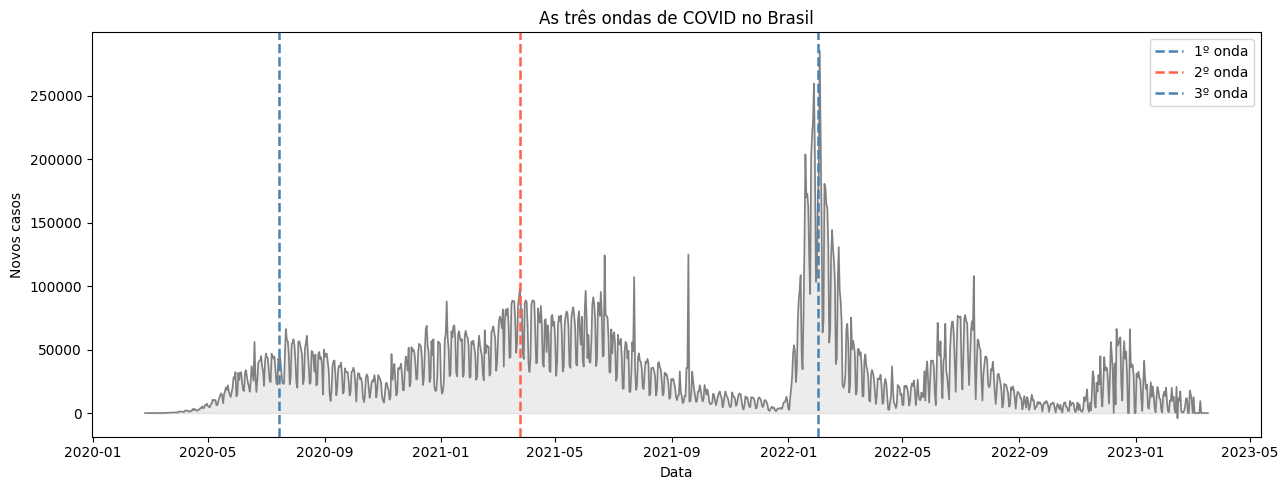

In [37]:
from matplotlib import lines
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['newCases'], color='gray', linewidth=1.2)
ax.fill_between(df['date'], df['newCases'], alpha=0.15, color='gray')
for nome, data, cor in ondas:
  ax.axvline(pd.to_datetime(data), color=cor, linestyle="--", linewidth=1.8, label=nome)

ax.set_title("As três ondas de COVID no Brasil")
ax.set_xlabel("Data")
ax.set_ylabel("Novos casos")
ax.legend()
plt.tight_layout()
plt.show()


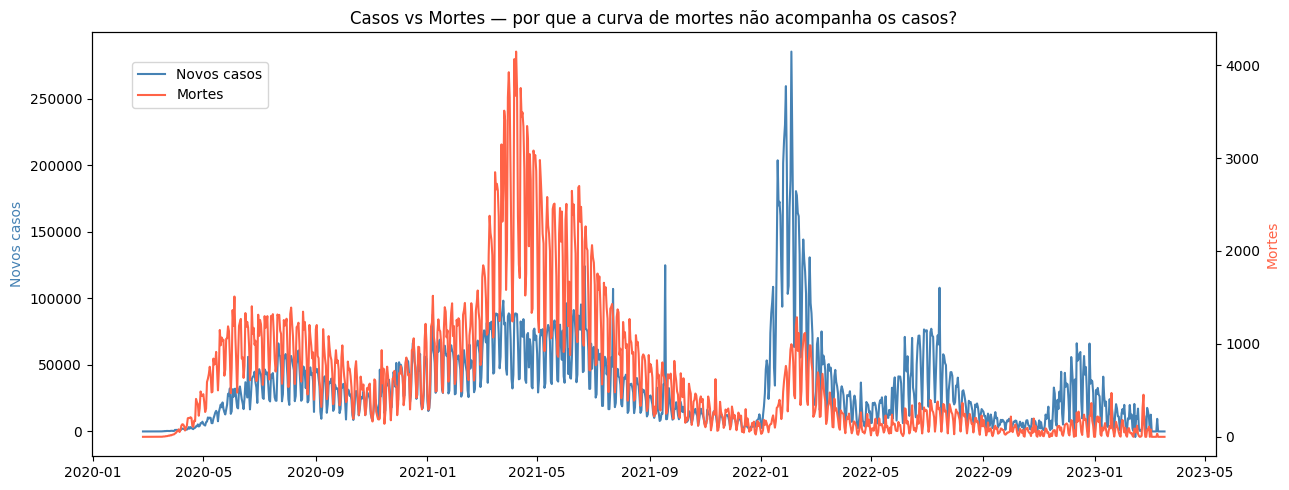

In [38]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(df['date'], df['newCases'], color='steelblue', label='Novos casos')
ax1.set_ylabel('Novos casos', color='steelblue')

ax2 = ax1.twinx()  # segundo eixo Y no mesmo gráfico
ax2.plot(df['date'], df['newDeaths'], color='tomato', label='Mortes', linewidth=1.5)
ax2.set_ylabel('Mortes', color='tomato')

ax1.set_title("Casos vs Mortes — por que a curva de mortes não acompanha os casos?")
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))

plt.tight_layout()
plt.show()

/tmp/ipykernel_3640/1658510478.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


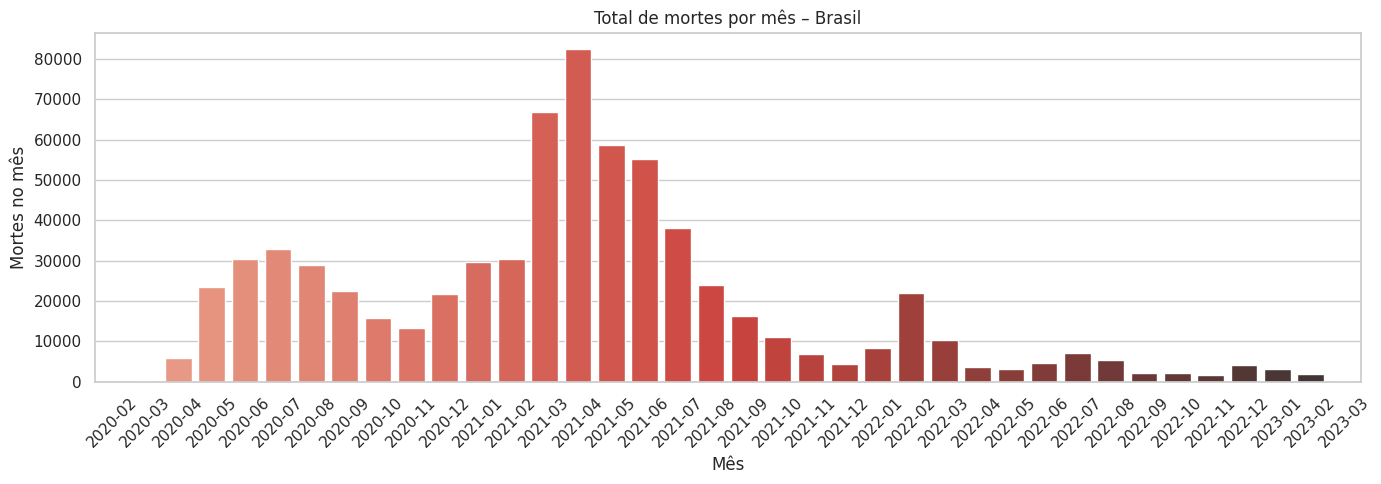

In [39]:
df['mes'] = df['date'].dt.to_period('M').astype(str)

sns.set(style="whitegrid")
plt.figure(figsize=(14, 5))

sns.barplot(
    data=df, x='mes', y='newDeaths',
    estimator='sum', errorbar=None, palette='Reds_d'
)

plt.title("Total de mortes por mês – Brasil")
plt.xlabel("Mês")
plt.ylabel("Mortes no mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()